# 03｜训练第一个 MLP

本页先训练一个完整模型，观察决策边界如何随 Epoch 形成；随后用五张小图把神经元、Linear、激活函数、分类输出和一次参数更新逐层拆开。

重点是看懂数据怎样流过模型，不需要先追求最高准确率。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "mlp_lab").is_dir():
    LAB_DIR = (Path.cwd() / "01_mlp_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from mlp_lab import quick_demo

## 在三分类螺旋数据上训练

共享服务器默认使用 CPU。只有获得课堂分配后，才使用第 `x` 块 GPU。


配置对比
--------------------------------------------------------------------------------------
配置                                   测试准确率         参数量       耗时(秒)          末轮梯度
--------------------------------------------------------------------------------------
spiral｜relu｜adam                    98.2%       1,251        0.21        0.6667
--------------------------------------------------------------------------------------


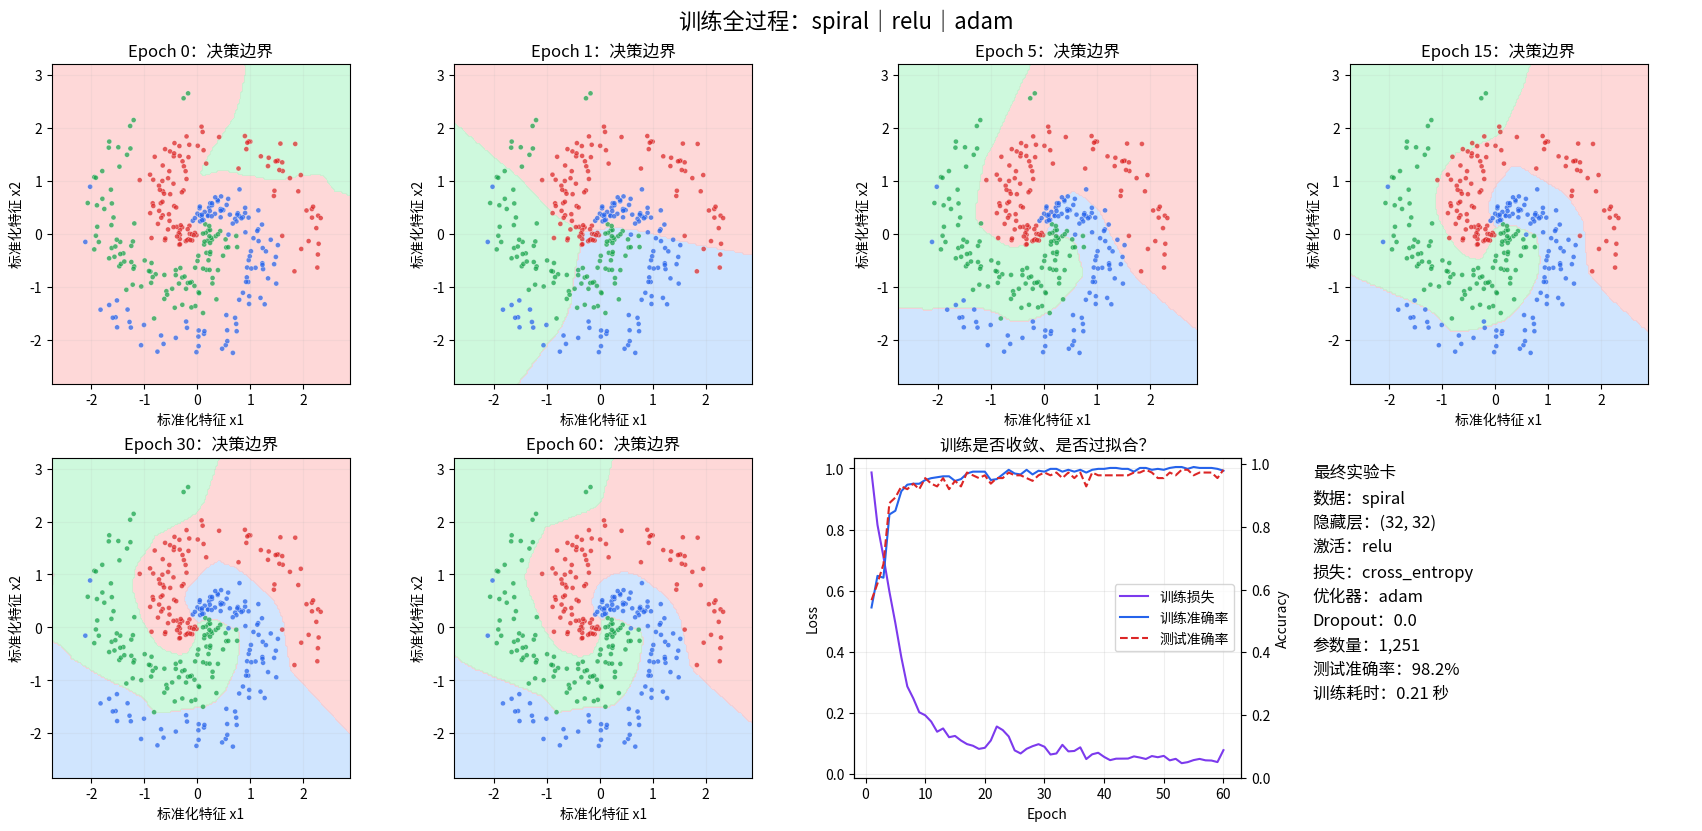

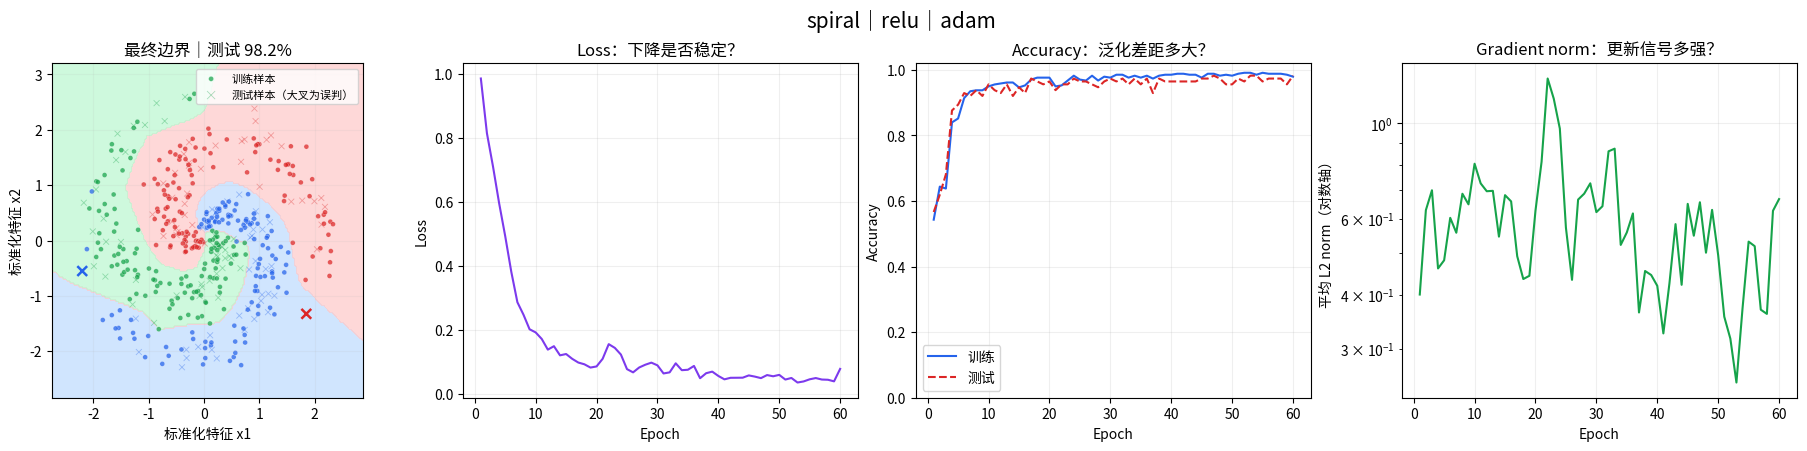

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

result = quick_demo(
    dataset="spiral",
    hidden_sizes=(32, 32),
    activation="relu",
    optimizer="adam",
    device=DEVICE,
    epochs=60,
    n_samples=450,
)

## 1｜从一个神经元开始：先加权，再激活

一个神经元先把输入乘以权重、加上偏置，再交给激活函数：

$$
z=x_1w_1+x_2w_2+b,\qquad a=\operatorname{ReLU}(z)=\max(0,z)
$$

可以把权重理解为每个输入的“影响方向和强度”，偏置负责整体平移。下面先算一个具体样本。

**先猜再运行：**因为 $x_2$ 和 $w_2$ 都是负数，$x_2w_2$ 会对加权和产生正贡献还是负贡献？

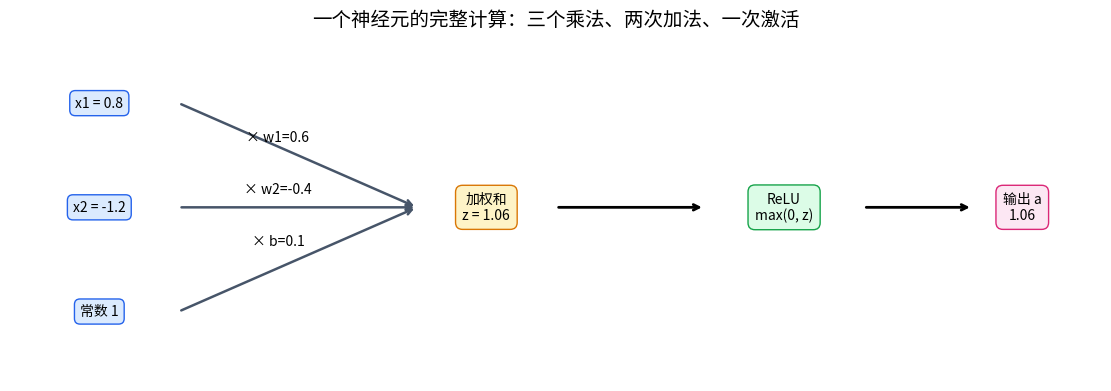

z = 0.8×0.6 + (-1.2)×(-0.4) + 0.1 = 1.06
a = ReLU(z) = 1.06


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from mlp_lab.plots import configure_chinese_font

configure_chinese_font()
x1, x2 = 0.8, -1.2
w1, w2, b = 0.6, -0.4, 0.1
z = x1 * w1 + x2 * w2 + b
a = max(0.0, z)

fig, ax = plt.subplots(figsize=(11, 3.8), layout="constrained")
ax.set(xlim=(0, 11), ylim=(0, 3))
ax.axis("off")
inputs = [(0.9, 2.4, f"x1 = {x1}"), (0.9, 1.5, f"x2 = {x2}"), (0.9, 0.6, "常数 1")]
for x, y, text in inputs:
    ax.text(x, y, text, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.4", fc="#DBEAFE", ec="#2563EB"))
for (_, y, _), label in zip(inputs, [f"× w1={w1}", f"× w2={w2}", f"× b={b}"]):
    ax.annotate("", xy=(4.1, 1.5), xytext=(1.7, y),
                arrowprops=dict(arrowstyle="->", lw=1.8, color="#475569"))
    ax.text(2.7, (y + 1.5) / 2 + 0.12, label, ha="center", fontsize=10)
ax.text(4.8, 1.5, f"加权和\nz = {z:.2f}", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5", fc="#FEF3C7", ec="#D97706"))
ax.annotate("", xy=(7.0, 1.5), xytext=(5.5, 1.5), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(7.8, 1.5, "ReLU\nmax(0, z)", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5", fc="#DCFCE7", ec="#16A34A"))
ax.annotate("", xy=(9.7, 1.5), xytext=(8.6, 1.5), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(10.2, 1.5, f"输出 a\n{a:.2f}", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5", fc="#FCE7F3", ec="#DB2777"))
ax.set_title("一个神经元的完整计算：三个乘法、两次加法、一次激活", fontsize=14)
plt.show()

print(f"z = {x1}×{w1} + ({x2})×({w2}) + {b} = {z:.2f}")
print(f"a = ReLU(z) = {a:.2f}")

## 2｜一个神经元变成一层：看懂 `Linear` 的形状

如果一个 Batch 有 $B$ 个样本，每个样本有 2 个特征，而 Linear 层有 $H$ 个输出，那么：

$$
X_{[B,2]}W_{[2,H]}+b_{[H]}=Z_{[B,H]}
$$

PyTorch 把权重保存为 `[H, 2]`，计算时使用它的转置 `weight.T`。下面让 3 个样本同时通过 4 个神经元。

**形状检查：**Batch 大小从 3 改为 5 时，哪些维度会跟着变化，哪些不会？

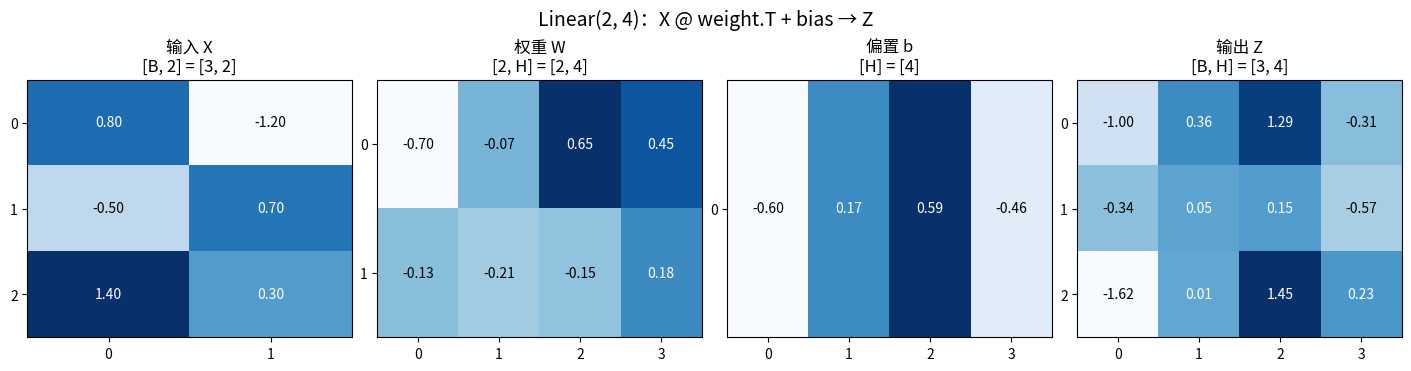

PyTorch 保存的 weight.shape： (4, 2)
用于矩阵乘法的 weight.T.shape： (2, 4)


In [4]:
batch = torch.tensor([[0.8, -1.2], [-0.5, 0.7], [1.4, 0.3]])
linear = nn.Linear(in_features=2, out_features=4)
with torch.no_grad():
    linear_output = linear(batch)

panels = [
    (batch.numpy(), "输入 X", "[B, 2] = [3, 2]"),
    (linear.weight.T.detach().numpy(), "权重 W", "[2, H] = [2, 4]"),
    (linear.bias.detach().numpy()[None, :], "偏置 b", "[H] = [4]"),
    (linear_output.detach().numpy(), "输出 Z", "[B, H] = [3, 4]"),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), layout="constrained")
for ax, (values, title, shape_text) in zip(axes, panels):
    ax.imshow(values, cmap="Blues", aspect="auto")
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            text_color = "white" if values[row, column] > (values.min() + values.max()) / 2 else "black"
            ax.text(column, row, f"{values[row, column]:.2f}",
                    ha="center", va="center", color=text_color)
    ax.set_title(f"{title}\n{shape_text}")
    ax.set_xticks(range(values.shape[1]))
    ax.set_yticks(range(values.shape[0]))
fig.suptitle("Linear(2, 4)：X @ weight.T + bias → Z", fontsize=14)
plt.show()

print("PyTorch 保存的 weight.shape：", tuple(linear.weight.shape))
print("用于矩阵乘法的 weight.T.shape：", tuple(linear.weight.T.shape))
assert linear_output.shape == (3, 4)

## 3｜为什么 Linear 后面需要激活函数？

只把多个 Linear 连在一起，整体仍然只能表示一次线性变换。激活函数在中间加入“弯折”，MLP 才能形成曲线决策边界。

先观察三条曲线：同一个输入 $z$，经过不同激活函数会得到不同输出。

**观察问题：**当 $z=-2$ 时，三种激活函数分别保留了多少信息？

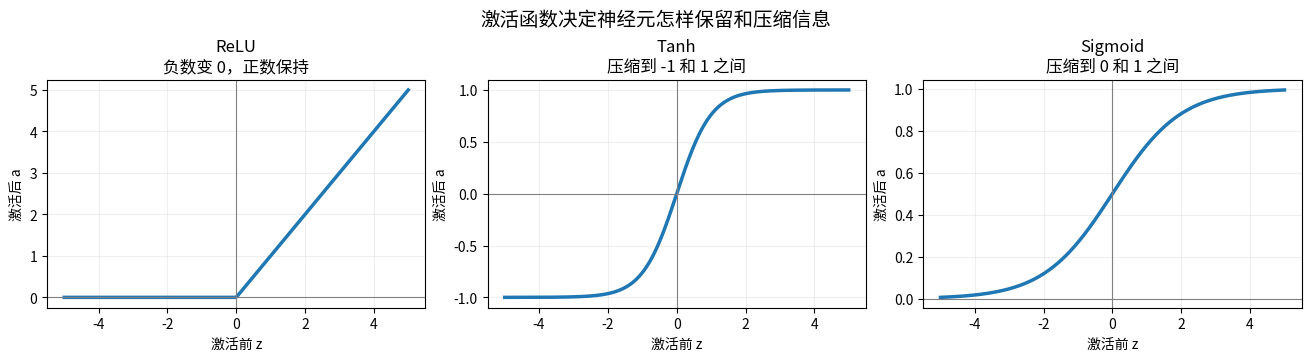

In [5]:
z_values = torch.linspace(-5, 5, 300)
activations = [
    ("ReLU", torch.relu(z_values), "负数变 0，正数保持"),
    ("Tanh", torch.tanh(z_values), "压缩到 -1 和 1 之间"),
    ("Sigmoid", torch.sigmoid(z_values), "压缩到 0 和 1 之间"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharex=True, layout="constrained")
for ax, (name, output, description) in zip(axes, activations):
    ax.plot(z_values, output, lw=2.5)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set(title=f"{name}\n{description}", xlabel="激活前 z", ylabel="激活后 a")
    ax.grid(alpha=0.2)
fig.suptitle("激活函数决定神经元怎样保留和压缩信息", fontsize=14)
plt.show()

## 4｜从 logits 到类别和 Loss

分类 MLP 的最后一层为每个类别输出一个原始分数，叫作 **logit**。logit 不要求位于 0 到 1，也不要求总和为 1。

- `softmax` 把 logits 转成总和为 1 的概率；
- `argmax` 选择分数最大的类别；
- `CrossEntropyLoss` 比较 logits 与真实类别。

> `nn.CrossEntropyLoss` 内部已经完成所需的 log-softmax 计算，训练时直接传 logits，不要先手动 softmax。

**先猜再运行：**三个 logits 中哪个最大？预测类别会是什么？概率之和应该是多少？

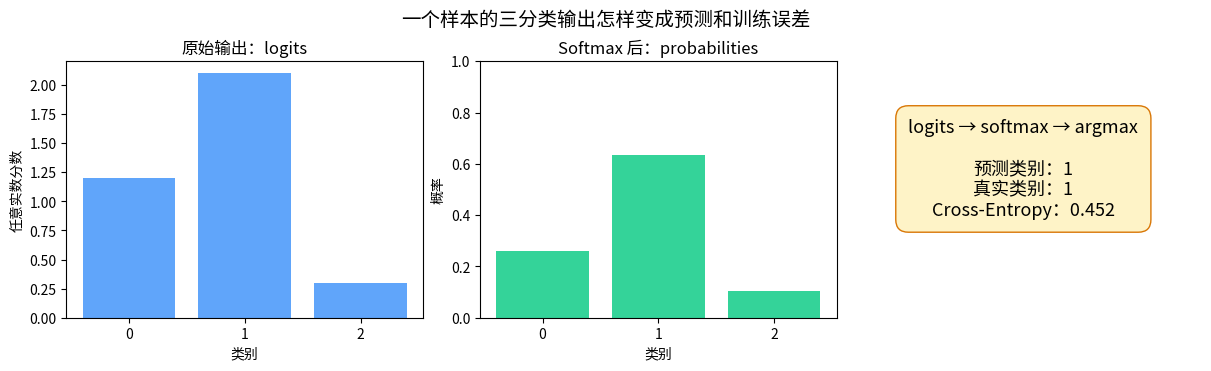

概率总和： 1.0


In [6]:
logits = torch.tensor([[1.2, 2.1, 0.3]])
true_label = torch.tensor([1])
probabilities = torch.softmax(logits, dim=1)
prediction = logits.argmax(dim=1)
classification_loss = F.cross_entropy(logits, true_label)

classes = np.arange(logits.shape[1])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), layout="constrained")
axes[0].bar(classes, logits[0], color="#60A5FA")
axes[0].set(title="原始输出：logits", xlabel="类别", ylabel="任意实数分数", xticks=classes)
axes[1].bar(classes, probabilities[0], color="#34D399")
axes[1].set(title="Softmax 后：probabilities", xlabel="类别", ylabel="概率", xticks=classes, ylim=(0, 1))
axes[2].axis("off")
axes[2].text(0.5, 0.58,
             f"logits → softmax → argmax\n\n预测类别：{prediction.item()}\n真实类别：{true_label.item()}\nCross-Entropy：{classification_loss.item():.3f}",
             ha="center", va="center", fontsize=13,
             bbox=dict(boxstyle="round,pad=0.7", fc="#FEF3C7", ec="#D97706"))
fig.suptitle("一个样本的三分类输出怎样变成预测和训练误差", fontsize=14)
plt.show()

print("概率总和：", probabilities.sum().item())
assert torch.allclose(probabilities.sum(), torch.tensor(1.0))

## 5｜一次训练 Step：参数到底怎样改变？

下面建立一个很小的 `2 → 3 → 2` MLP，只训练一个 Batch、只更新一次。五个动作与完整实验完全相同：

```text
zero_grad → forward → loss → backward → step
```

为了让图不太拥挤，只展示第一层的权重。蓝红颜色表示正负方向，每个格子的数字才是实际数值。

**观察问题：**梯度为正的位置，参数更新后应该增大还是减小？

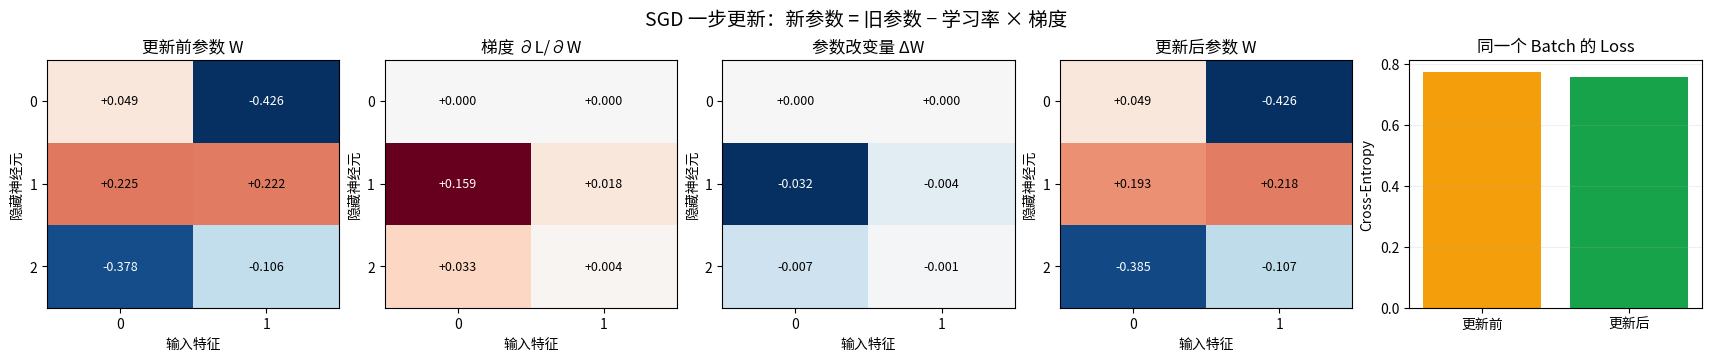

Loss：0.7753 → 0.7578
检查 ΔW = -learning_rate × gradient： True


In [7]:
torch.manual_seed(7)
train_x = torch.tensor([[1.0, 0.0], [0.8, 0.2], [-1.0, 0.0], [-0.8, -0.2]])
train_y = torch.tensor([1, 1, 0, 0])
tiny_mlp = nn.Sequential(nn.Linear(2, 3), nn.ReLU(), nn.Linear(3, 2))
learning_rate = 0.2
optimizer = torch.optim.SGD(tiny_mlp.parameters(), lr=learning_rate)

weight_before = tiny_mlp[0].weight.detach().clone()
optimizer.zero_grad()
step_logits = tiny_mlp(train_x)
loss_before = F.cross_entropy(step_logits, train_y)
loss_before.backward()
weight_gradient = tiny_mlp[0].weight.grad.detach().clone()
optimizer.step()
weight_after = tiny_mlp[0].weight.detach().clone()
weight_change = weight_after - weight_before
with torch.no_grad():
    loss_after = F.cross_entropy(tiny_mlp(train_x), train_y)

matrices = [
    ("更新前参数 W", weight_before),
    ("梯度 ∂L/∂W", weight_gradient),
    ("参数改变量 ΔW", weight_change),
    ("更新后参数 W", weight_after),
]
fig, axes = plt.subplots(1, 5, figsize=(17, 3.5), layout="constrained")
for ax, (title, matrix) in zip(axes[:4], matrices):
    values = matrix.numpy()
    limit = max(float(np.abs(values).max()), 1e-6)
    ax.imshow(values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            text_color = "white" if abs(values[row, column]) > limit * 0.55 else "black"
            ax.text(column, row, f"{values[row, column]:+.3f}",
                    ha="center", va="center", color=text_color, fontsize=9)
    ax.set(title=title, xlabel="输入特征", ylabel="隐藏神经元")
    ax.set_xticks(range(values.shape[1]))
    ax.set_yticks(range(values.shape[0]))
axes[4].bar(["更新前", "更新后"], [loss_before.item(), loss_after.item()],
            color=["#F59E0B", "#16A34A"])
axes[4].set(title="同一个 Batch 的 Loss", ylabel="Cross-Entropy")
axes[4].grid(axis="y", alpha=0.2)
fig.suptitle("SGD 一步更新：新参数 = 旧参数 − 学习率 × 梯度", fontsize=14)
plt.show()

print(f"Loss：{loss_before.item():.4f} → {loss_after.item():.4f}")
print("检查 ΔW = -learning_rate × gradient：",
      torch.allclose(weight_change, -learning_rate * weight_gradient, atol=1e-6))
assert loss_after < loss_before

## 6｜把前面的五张图对应回真正的 MLP

现在再打印刚才训练的完整模型：每个 `Linear` 都执行一次加权和，每个 `ReLU` 都加入一次非线性；最后一个 `Linear` 输出三个类别的 logits。

阅读时从上到下跟踪形状：`[B,2] → [B,32] → [B,32] → [B,3]`。

In [8]:
print(result.model)
print("可训练参数量：", result.parameter_count)

MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)
可训练参数量： 1251


### 读 `MLP` 类时先认出四件事

- `class MLP(nn.Module)`：`MLP` 继承 PyTorch 的模型基类；
- `super().__init__()`：先完成父类初始化，PyTorch 才能登记各层参数；
- `self.network`：把层保存在当前模型对象中；
- `forward(self, x)`：说明输入 `x` 怎样依次通过这些层。平时写 `result.model(x)`，PyTorch 会自动调用 `forward()`，不要手动写 `forward(x)`。

**观察顺序：**先看边界形状，再看 Loss 是否下降，最后比较训练集与测试集 Accuracy。一次实验只能说明当前数据、参数和随机种子下的现象。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)
